The purpose of this notebook is to generate plots for the required variance in methane forcing to achieve a given variance in the observed methane time series.

In [1]:
from methane_noise_forcing import closed_form, average_to_resolution, calculate_mean_and_ci
from hydra import compose, initialize
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
import pandas as pd
import xarray as xr
import numpy as np
from methane_noise_forcing.core import FirnFilter
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
)
from methane_noise_forcing.noise import simulate_two_timescale_ar1
from scipy.stats import gaussian_kde
plt.rcParams.update(matplotlib_rcparams)

In [2]:
## figure settings
fig_width = fig_width_options["one_column"]

In [3]:
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config", overrides=[
        "+noise=white_noise_ar1",
        "++noise.duration_timeseries=4750",
        "+firn_kernel=firn_model_wais",])

In [4]:
## global parameters
variance_filtered_methane = 100 # ppb^2
taus_methane = np.arange(7, 13.2, 0.2) # years

# parameters for sweeping forcing timescale
a, b = -2, 3 # log10 years
m = 10 # samples per decade
num = (b - a) * m + 1 # number of samples
taus_forcing = np.logspace(a, b, num) # years

# lags to calculate
n_lag_years = 80 # number of year lags to calculate

In [5]:
## plotting functions
def plot_da_heat(
    da,
    *,
    ax=None,                 # main plotting axes
    cbar_ax=None,            # optional separate axes for the colorbar
    cmap='Reds',
    log_color=False,         # True => LogNorm for both image & colorbar
    vmin=None,
    vmax=None,
    cbar_label=None,
    cbar_orientation='vertical',  # 'vertical' or 'horizontal'
    tight=False,
    **kwargs
):
    """
    da: xarray.DataArray with dims ('taus_methane', 'taus_forcing')
    Returns: (h, ax, cbar)
    """
    if ax is None:
        ax = plt.gca()

    # Norm controls both the image mapping and the colorbar scale
    norm = mcolors.LogNorm(vmin=vmin, vmax=vmax) if log_color else None

    # Build kwargs for xarray's plot
    plot_kwargs = dict(
        x='taus_forcing',
        y='taus_methane',
        ax=ax,
        cmap=cmap,
        norm=norm,
        add_colorbar=True
    )
    if cbar_ax is not None:
        plot_kwargs['cbar_ax'] = cbar_ax
    # Only pass cbar_kwargs if we actually set something, to avoid overriding defaults
    cbar_kwargs = {}
    if cbar_label is not None:
        cbar_kwargs['label'] = cbar_label
    if cbar_orientation != 'vertical':
        cbar_kwargs['orientation'] = cbar_orientation
    if cbar_kwargs:
        plot_kwargs['cbar_kwargs'] = cbar_kwargs

    plot_kwargs.update(kwargs)
    h = da.plot(**plot_kwargs)

    # Axes formatting
    ax.set_xscale('log')
    ax.set_xlabel('Forcing timescale (yr)')
    ax.set_ylabel('Methane lifetime (yr)')
    ax.set_title('')

    # Decimal tick labels on a log x-axis (0.01, 0.1, 1, 10, ...)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if tight:
        plt.tight_layout()

    # Grab the colorbar (xarray attaches it to the artist)
    cbar = h.colorbar
    return h, ax, cbar

def colorbar_decade_labels(cbar):
    vmin, vmax = cbar.norm.vmin, cbar.norm.vmax
    lo = int(np.ceil(np.log10(vmin)))
    hi = int(np.floor(np.log10(vmax)))
    ticks = [10**e for e in range(lo, hi+1)]
    if ticks:                      # only set if we actually have full decades in-range
        cbar.set_ticks(ticks)
    cbar.formatter = mticker.FuncFormatter(lambda v, pos: f"{v:g}")  # 1, 10, 100...
    cbar.update_ticks()

# generate and visualize kernel self-overlap (autocorrelation)

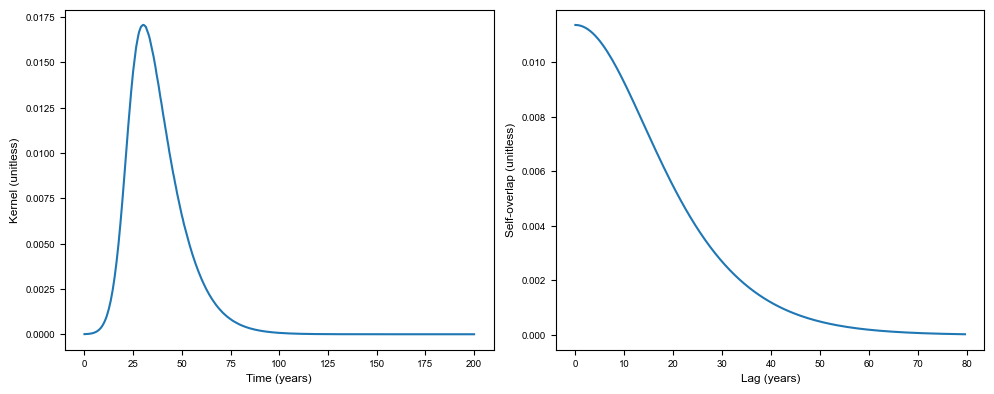

In [6]:
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root
)
# firn_filter = FirnFilter.fit_gamma(
#     mode=30,
#     fwhm=27,
#     skew=0.7,
#     t_max=200,
#     dt=0.1,
#     taper_fraction=0
# )

dt = firn_filter.dt  # years
lags = np.arange(0, n_lag_years / dt, 1) # years

# normalize kernel by ensuring unit area
# since series dt is equal to kernel dt, we can use the sum of the kernel directly
kernel_normalized = firn_filter.kernel / np.sum(firn_filter.kernel) 

# calculate self-overlap
c_taus = closed_form.calculate_kernel_self_lag(
    kernel=kernel_normalized,
    lags=lags,
)

# plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot firn filter
time = np.arange(0, kernel_normalized.shape[0] * dt, dt)
axs[0].plot(time, kernel_normalized)
axs[0].set_xlabel("Time (years)")
axs[0].set_ylabel("Kernel (unitless)")

# plot self-overlap
axs[1].plot(lags * dt, c_taus)
axs[1].set_xlabel("Lag (years)")
axs[1].set_ylabel("Self-overlap (unitless)")

plt.tight_layout()

# two-timescale noise

## generate autocorrelations for range of timescales

In [7]:
## iterate over methane lifetimes and forcing timescales to calculate autocorrelation over all lags
#  dimensions of output DataSet: (taus_methane, taus_forcing, lags)
autocorrelation_two_timescale = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing), len(lags))),
    dims=["taus_methane", "taus_forcing", "lags"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
        "lags": lags,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        autocorrelation = closed_form.calculate_two_timescale_autocorrelation(
            phi_0=np.exp(-dt / tau_methane),
            phi_1=np.exp(-dt / tau_forcing),
            lags=lags,
        )
        autocorrelation_two_timescale.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = autocorrelation

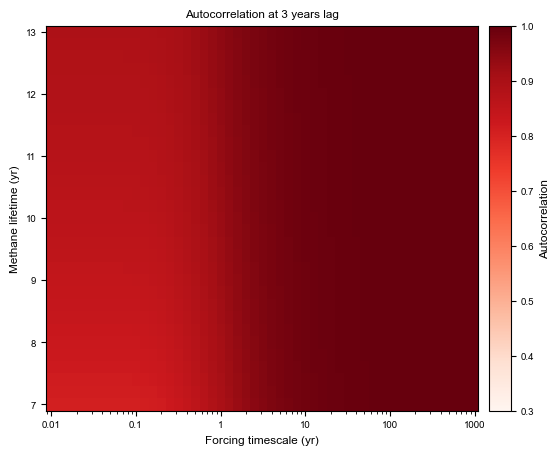

In [8]:
## plot autocorrelations at specific lags
lag_years = 3 # years
da_to_plot = autocorrelation_two_timescale.sel(lags=lag_years)

fig = plt.figure(figsize=(6,5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[0,1]) 

h, ax, cbar = plot_da_heat(
    da_to_plot,
    ax=ax, cbar_ax=cax,
)
h.set_clim(0.3, 1)
h.set_label('something')
ax.set_title(f'Autocorrelation at {lag_years} years lag')
cbar = h.colorbar
cbar.set_label('Autocorrelation')

## calculate variance required in atmospheric methane and forcing

In [9]:
## iterate over methane lifetimes and forcing timescales to calculate atmospheric methane and forcing variances
#  dimensions of output DataSet: (taus_methane, taus_forcing)
atmospheric_methane_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
forcing_variance = xr.DataArray(
    np.zeros((len(taus_methane), len(taus_forcing))),
    dims=["taus_methane", "taus_forcing"],
    coords={
        "taus_methane": taus_methane,
        "taus_forcing": taus_forcing,
    },
)
for tau_methane in taus_methane:
    for tau_forcing in taus_forcing:
        variance_ratio_filtered_to_atmospheric = closed_form.calculate_variance_ratio_filtered_to_instantaneous(
            c_taus=c_taus,
            instantaneous_autocorrelations=autocorrelation_two_timescale.loc[dict(
                taus_methane=tau_methane,
                taus_forcing=tau_forcing,
            )],
        )
        variance_atmospheric_methane = variance_filtered_methane / variance_ratio_filtered_to_atmospheric
        atmospheric_methane_variance.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = variance_atmospheric_methane

        variance_ratio_methane_to_forcing = closed_form.calculate_two_timescale_variance_ratio_methane_to_ar1_forcing(
            tau_methane=tau_methane,
            tau_forcing=tau_forcing,
        )
        variance_forcing = variance_atmospheric_methane / variance_ratio_methane_to_forcing
        forcing_variance.loc[dict(
            taus_methane=tau_methane,
            taus_forcing=tau_forcing,
        )] = variance_forcing

# convert units of variance from ppb^2/yr^2 to Tg^2/yr^2
# 1 ppb = 2.75 Tg of methane
conversion_factor = 2.75
variance_forcing *= conversion_factor**2

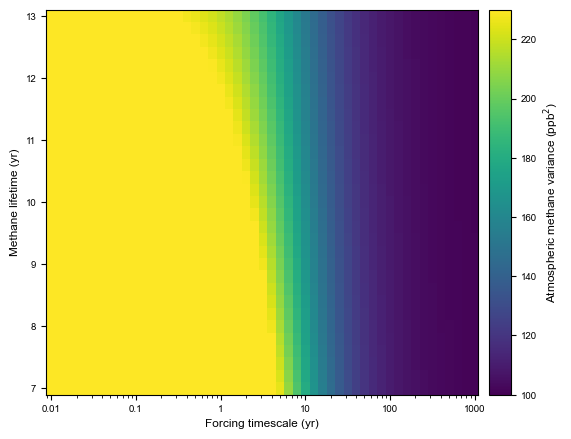

In [10]:
## plot atmospheric methane variance required for a given filtered variance
fig = plt.figure(figsize=(6,5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[0,1]) 

h, ax, cbar = plot_da_heat(
    atmospheric_methane_variance,
    ax=ax, cbar_ax=cax,
    cmap='viridis',
)
cbar = h.colorbar
cbar.set_label('Atmospheric methane variance (ppb$^2$)')
h.set_clim(100, 230)  

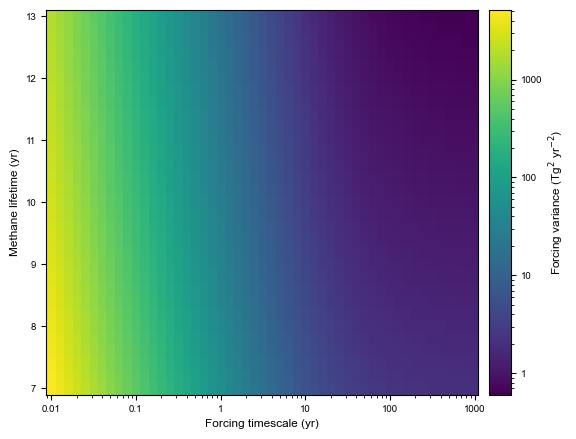

In [11]:
## plot forcing variance required
fig = plt.figure(figsize=(6,5))
gs = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[20, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0,0])
cax = fig.add_subplot(gs[0,1]) 

h, ax, cbar = plot_da_heat(
    forcing_variance,
    ax=ax, cbar_ax=cax,
    cmap='viridis',
    log_color=True,
)
cbar = h.colorbar
cbar.set_label('Forcing variance (Tg$^2$ yr$^{-2}$)')
colorbar_decade_labels(cbar)

# compare growth rate to modern methane

In [12]:
data_dir = Path(cfg.paths.observations_cultivated)
obs_modern = pd.read_csv(data_dir / "ch4_growth_modern_detrended.csv")
# absolute value of growth rate
obs_modern['ch4_growth_detrended_abs'] = np.abs(obs_modern['ch4_growth_detrended'])

In [13]:
## function for simulating noise
def simulate_multiple_realizations(timescales, var_C_target, tau_C, n_years, dt, n_ensemble):
    """
    Simulate multiple realizations of methane time series with different forcing timescales.
    
    Parameters:
    - timescales: list of forcing timescales (in years)
    - var_C_target: target variance of methane concentration (in ppb^2)
        - can be a single value or a list of values with the same length and order as timescales
    """
    two_timescale_noise = []
    for i, tau_eta in enumerate(timescales):
        if isinstance(var_C_target, (list, np.ndarray)):
            var_C = var_C_target[i]
        else:
            var_C = var_C_target
        
        x_ens, eta_ens = simulate_two_timescale_ar1(
            tau_x=tau_C,
            tau_eta=tau_eta,
            variance_x=var_C,
            n_steps=int(n_years / dt),
            dt=dt,
            n_ens=n_ensemble,
        )
        
        ds = xr.Dataset(
        {
            "ch4": (("ensemble", "time"), x_ens),
            "forcing": (("ensemble", "time"), eta_ens),
        },
        coords={
            "time": (("time"), np.arange(0, n_years, dt)),
            "ensemble": (("ensemble"), np.arange(n_ensemble)),
        },
    )
        # add dim for timescale to dataset
        ds = ds.expand_dims({"forcing_timescale": [tau_eta]})
        ds = ds.assign_coords({"forcing_timescale": ("forcing_timescale", [tau_eta])})

        two_timescale_noise.append(ds)
    return xr.concat(two_timescale_noise, dim="forcing_timescale")

In [14]:
## simulate with multiple methane variance targets across timescales
timescales = [0.01, 0.1, 1.0, 10.0, 100, 1000]
var_C_target = 100.0  # Target variance for methane anomaly in ppb^2
n_ensemble = 100
tau_C = 10 # years
dt_small = 0.01 # Time step in years
n_years = 1000 # years

two_timescale_noise = simulate_multiple_realizations(
    timescales=timescales,
    var_C_target=atmospheric_methane_variance.sel(taus_methane=tau_C, taus_forcing=timescales, method="nearest").values,
    tau_C=tau_C,
    n_years=n_years,
    dt=dt_small,
    n_ensemble=n_ensemble
)

In [15]:
## average to annual resolution, then calculate growth over some lag
dt_annual = 1.0
change_interval = 1

two_timescale_noise_annual = average_to_resolution(two_timescale_noise, resolution=dt_annual, time_dim="time")

# lagged difference: x[t] - x[t-lag]
noise_change = two_timescale_noise_annual - two_timescale_noise_annual.shift(time=change_interval)
# drop the leading NaNs introduced by the shift
noise_change = noise_change.isel(time=slice(change_interval, None))

noise_change_abs = np.abs(noise_change)

# validation
ch4_annual_slice = two_timescale_noise_annual.ch4.isel(ensemble=0, forcing_timescale=0).values
ch4_change_direct = ch4_annual_slice[change_interval:] - ch4_annual_slice[:-change_interval]
np.allclose(noise_change.ch4.isel(ensemble=0, forcing_timescale=0).values, ch4_change_direct)

True

# plot

In [16]:
def annotate_panel(ax, text, loc="left", pad=0.01, color='k', **kwargs):
    """Place bold text at the top-left/right inside an axis."""
    x = pad if loc == "left" else 1 - pad
    ha = "left" if loc == "left" else "right"
    ax.text(
        x,
        0.99,
        text,
        transform=ax.transAxes,
        ha=ha,
        va="top",
        fontweight="bold",
        color=color,
        **kwargs
    )

<>:179: SyntaxWarning: invalid escape sequence '\m'
<>:181: SyntaxWarning: invalid escape sequence '\m'
<>:183: SyntaxWarning: invalid escape sequence '\m'
<>:179: SyntaxWarning: invalid escape sequence '\m'
<>:181: SyntaxWarning: invalid escape sequence '\m'
<>:183: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_89551/3015609260.py:179: SyntaxWarning: invalid escape sequence '\m'
  "(a) \u03C3$\mathregular{_c}$²/\u03C3$\mathregular{_{ice}}\mathregular{_{ }}\mathregular{_{core}}$²"
/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_89551/3015609260.py:181: SyntaxWarning: invalid escape sequence '\m'
  annotate_panel(ax_change, "(b) |$\mathregular{\Delta C_{annual}}$|")
/var/folders/sv/shxzb74j0557hzfx0_s5_n4r0000gn/T/ipykernel_89551/3015609260.py:183: SyntaxWarning: invalid escape sequence '\m'
  annotate_panel(ax_forcing, "(d) \u03C3$\mathregular{_{\\varepsilon}}$²")


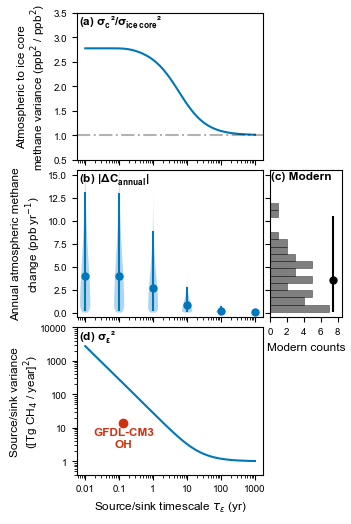

In [17]:
## draft of forcing plot
tau_methane = 10.0  # years
xlim= (0.0056, 1778)
xlim_modern = (0, 8.5)
xticks_modern = (0, 2, 4, 6, 8)
ylim_atmospheric = (0.5, 3.5)
ylim_change = (-0.5, 15.5)
ylim_forcing = (0.4, 10000)
# violin plot params
density_points = 256
width_decades = 0.15   # controls violin half-width in log10 space
alpha_fill = 0.3
da_to_plot_forcing = forcing_variance.sel(taus_methane=tau_methane, method='nearest')
da_to_plot_methane = atmospheric_methane_variance.sel(taus_methane=tau_methane, method='nearest')

fig = plt.figure(figsize=(fig_width_options["one_column"], 3 * 2))
gs = GridSpec(
    nrows=3,
    ncols=2,
    width_ratios=[2.6, 1],
    figure=fig,
    hspace=0.07,
    wspace=0.05
)

## atmospheric methane variance
ax_atmospheric = fig.add_subplot(gs[0, 0])
ax_atmospheric.plot(
    da_to_plot_methane.taus_forcing,
    da_to_plot_methane / variance_filtered_methane,
    color=colors_vibrant["blue"]
)
ax_atmospheric.axhline(1, color="k", linestyle="-.", alpha=0.3)
ax_atmospheric.set_xscale('log')
ax_atmospheric.set_xlim(xlim)
ax_atmospheric.set_xticklabels([])
ax_atmospheric.set_ylim(ylim_atmospheric)
ax_atmospheric.set_ylabel('Atmospheric to ice core\nmethane variance (ppb$^2$ / ppb$^2$)')

## atmospheric growth (change) rate
# paleo
ax_change = fig.add_subplot(gs[1, 0])
ax_change.set_xscale('log')
ax_change.set_xlim(xlim)
ax_change.set_ylim(ylim_change)
violin_data = [] 
violin_positions = [] 
for timescale in timescales: 
    data = noise_change_abs.ch4.sel(forcing_timescale=timescale).values.flatten() # remove any NaN values 
    data = data[~np.isnan(data)]
    violin_data.append(data)
    violin_positions.append(timescale)
for x0, timescale in zip(violin_positions, timescales):
    data = noise_change_abs.ch4.sel(forcing_timescale=timescale).values.ravel()
    data = data[~np.isnan(data)]
    if data.size == 0:
        continue

    # Data support (clip range)
    dmin, dmax = np.min(data), np.max(data)

    # KDE fit
    kde = gaussian_kde(data)

    # y-grid clipped to [dmin, dmax]
    y = np.linspace(dmin, dmax, density_points)
    v = kde(y)

    # normalize density to [0, 1]
    v = v / v.max()

    # Convert density to symmetric half-width in decades
    half_width_decades = width_decades * v
    m = 10.0 ** half_width_decades

    # Symmetric envelopes in log space
    x_left = x0 / m
    x_right = x0 * m

    # Clip to plotting range
    x_left = np.clip(x_left, xlim[0], xlim[1])
    x_right = np.clip(x_right, xlim[0], xlim[1])

    # Draw violin
    ax_change.fill_betweenx(
        y, x_left, x_right,
        facecolor=colors_vibrant["blue"], edgecolor='none',
        alpha=alpha_fill
    )

    # Overlay error bars (median + CI)
    mean, ci_lower, ci_upper = calculate_mean_and_ci(
        noise_change_abs.ch4.sel(forcing_timescale=timescale),
        dim=["ensemble", "time"]
    )
    median = noise_change_abs.ch4.sel(forcing_timescale=timescale).median(dim=["ensemble", "time"])

    ax_change.errorbar(
        x0,
        float(median),
        yerr=[[float(median - ci_lower)], [float(ci_upper - median)]],
        fmt='o',
        markersize=5,
        color=colors_vibrant["blue"],
        zorder=10,
    )
ax_change.set_ylabel(f'Annual atmospheric methane\nchange (ppb yr$^{{-1}}$)')
ax_change.set_xticklabels([])
# modern methane
ax_modern = fig.add_subplot(gs[1, 1])
obs_modern["ch4_growth_detrended_abs"].hist(
    ax=ax_modern,
    bins=15,
    density=False,
    alpha=0.5,
    orientation="horizontal",
    color='k',
    edgecolor='k',
    linewidth=0.5,
)
# add median and 95% CI as vertical line
median_modern = obs_modern["ch4_growth_detrended_abs"].median()
ci_lower_modern = obs_modern["ch4_growth_detrended_abs"].quantile(0.025)
ci_upper_modern = obs_modern["ch4_growth_detrended_abs"].quantile(0.975)
ax_modern.errorbar(
    7.5,
    float(median_modern),
    yerr=[[float(median_modern - ci_lower_modern)], [float(ci_upper_modern - median_modern)]],
    fmt='o',
    markersize=5,
    color='k',
    zorder=10,
)
ax_modern.set_ylim(ylim_change)
ax_modern.set_yticklabels([])
ax_modern.set_xlim(xlim_modern)
ax_modern.set_xticks(xticks_modern)
ax_modern.set_xlabel('Modern counts', labelpad=4.5)
ax_modern.grid(False)

## forcing variance
ax_forcing = fig.add_subplot(gs[2, 0])
ax_forcing.plot(
    da_to_plot_forcing.taus_forcing,
    da_to_plot_forcing,
    color=colors_vibrant["blue"]
)
# add a point for OH
ax_forcing.plot(0.13, 14.4, 'o', color=colors_vibrant["red"])
ax_forcing.text(
        0.25,
        0.32,
        "GFDL-CM3\nOH",
        transform=ax_forcing.transAxes,
        ha="center",
        va="top",
        fontweight="bold",
        color=colors_vibrant["red"],
    )
# ax_forcing.axvline(white_noise_limit, color="k", linestyle="--", alpha=0.3)
ax_forcing.set_ylabel('Source/sink variance\n([Tg CH$_4$ / year]$^2$)', labelpad=-1)

ax_forcing.set_ylim(ylim_forcing)
ax_forcing.set_yscale('log')
ax_forcing.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax_forcing.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
ax_forcing.yaxis.set_minor_formatter(mticker.NullFormatter())

ax_forcing.set_xscale('log')
ax_forcing.set_xlim(xlim)
ax_forcing.set_xlabel('Source/sink timescale $\\tau_{\\varepsilon}$ (yr)')
ax_forcing.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax_forcing.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{v:g}"))
ax_forcing.xaxis.set_minor_formatter(mticker.NullFormatter())

## annotations
annotate_panel(
    ax_atmospheric,
    "(a) \u03C3$\mathregular{_c}$²/\u03C3$\mathregular{_{ice}}\mathregular{_{ }}\mathregular{_{core}}$²"
)
annotate_panel(ax_change, "(b) |$\mathregular{\Delta C_{annual}}$|")
annotate_panel(ax_modern, "(c) Modern")
annotate_panel(ax_forcing, "(d) \u03C3$\mathregular{_{\\varepsilon}}$²")


# # save figure in pdf format
# name = "fig_4"
# fig.savefig(
#     f"{cfg.paths.figures_dir}/for_publication/{name}.pdf", bbox_inches="tight", dpi=300
# )